# Tutorial 01 — Stress intensity factors of an inclined crack

**What you will learn**

- how a VCEM run is organized: an input workbook, this notebook as the orchestrator, and a
  stamped output directory with `provenance.md`;
- how to build a crack network, solve for its dislocation density, and extract $K_I$ and $K_{II}$;
- how to verify the solver against an exact solution and check that it converges.

**The problem.** A straight crack of length $2a$ sits in an infinite plate under a remote stress
$\boldsymbol{\sigma}^\infty$. The crack makes an angle $\beta$ with the $x$-axis. With unit
tangent $\mathbf{t} = (\cos\beta, \sin\beta)$ and normal $\mathbf{n} = (-\sin\beta, \cos\beta)$,
the exact stress intensity factors are

$$K_I = (\mathbf{n}\cdot\boldsymbol{\sigma}^\infty\cdot\mathbf{n})\sqrt{\pi a}, \qquad
  K_{II} = (\mathbf{t}\cdot\boldsymbol{\sigma}^\infty\cdot\mathbf{n})\sqrt{\pi a}.$$

Under uniaxial tension $\sigma_{yy}$ these become $K_I = \sigma\sqrt{\pi a}\cos^2\beta$ and
$K_{II} = \sigma\sqrt{\pi a}\sin\beta\cos\beta$. The crack opening displacement (COD) is the ellipse
$\delta(x) = (4\sigma_{nn}/E')\sqrt{a^2 - x^2}$.

**How VCEM solves it.** The crack is a distribution of edge dislocations on $N$ panels. The
dislocation densities are found by minimizing the traction on the crack faces subject to closure
(the KKT problem). $K_I$ and $K_{II}$ then come from a fit of the near-tip COD and sliding
displacement to $\sqrt{r}$.

**Runtime.** About three minutes with the Python engine.

## 1. Pick the case workbook

All parameters live in `input/inclined_crack.xlsx`. To change a value for one run only, put its `Symbol` in `OVERRIDES`. Overrides are recorded in `provenance.md`.

In [1]:
CASE_XLSX = "input/inclined_crack.xlsx"
OVERRIDES = {}              # e.g. {"n_crack_elements": 120, "sigma_xx": 50e6}
SHOW_PLOTS = True
QUIET = True                # hide solver log lines

## 2. Setup: paths, workbook, engine

In [2]:
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

TUT_DIR = Path.cwd()                          # this tutorial's folder
sys.path.insert(0, str(TUT_DIR.parent))       # tutorials/ -> tutorial_utils
import tutorial_utils as tu
tu.setup_paths()                              # vcem/ -> fracture_utils

from fracture_utils.Usolver.network import CrackNetworkV4
from fracture_utils.Usolver.material import Material, AppliedStress

# Read the workbook, apply this run's overrides, and flatten to {symbol: value}
case_path = (TUT_DIR / CASE_XLSX).resolve()
tables = tu.read_workbook(case_path)
overrides_applied = tu.apply_overrides(tables, OVERRIDES)
P = tu.flat_values(tables)

ENGINE, engine_note = tu.resolve_engine(P["engine"])
print(f"case     : {case_path.name}  (sha256 {tu.sha256(case_path)[:12]})")
print(f"sheets   : {', '.join(tables)}")
print(f"overrides: {overrides_applied or 'none'}")
print(f"engine   : {ENGINE}  — {engine_note}")

case     : inclined_crack.xlsx  (sha256 16353d2bc682)
sheets   : Material, Geometry, Loading, Solver, Verification, Output
overrides: none
engine   : python  — python engine requested


## 3. Build the model

`Material` holds the elastic constants and the plane condition. `AppliedStress` is the uniform
remote stress. `straight_crack(beta)` builds a one-edge crack network, and `exact_K(beta)` returns
the exact solution for comparison.

In [3]:
plane_stress = str(P["plane"]).lower().startswith("stress")
material = Material(E=float(P["E"]), nu=float(P["nu"]), plane_stress=plane_stress)
applied = AppliedStress(sigma_xx=float(P["sigma_xx"]), sigma_yy=float(P["sigma_yy"]),
                        sigma_xy=float(P["sigma_xy"]))

E, nu = float(P["E"]), float(P["nu"])
E_prime = E if plane_stress else E / (1.0 - nu**2)       # effective modulus
a = float(P["a"])
sig = np.array([[P["sigma_xx"], P["sigma_xy"]], [P["sigma_xy"], P["sigma_yy"]]], float)
K0 = float(P["sigma_yy"]) * np.sqrt(np.pi * a)           # reference SIF, sigma_yy * sqrt(pi a)


def straight_crack(beta_deg: float, half_length: float = a) -> CrackNetworkV4:
    """One straight crack through the origin at angle beta from the x-axis."""
    b = np.radians(beta_deg)
    c, s = np.cos(b), np.sin(b)
    V = np.array([[0, -half_length * c, -half_length * s],
                  [1, +half_length * c, +half_length * s]], float)
    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V, connectivity=np.array([[0, 1]]), Nv_max=3, validate=True)


def exact_K(beta_deg: float, half_length: float = a):
    """Griffith crack in an infinite plate: K_I = sigma_nn sqrt(pi a), K_II = sigma_nt sqrt(pi a)."""
    b = np.radians(beta_deg)
    t = np.array([np.cos(b), np.sin(b)])      # crack tangent
    n = np.array([-np.sin(b), np.cos(b)])     # crack normal
    root = np.sqrt(np.pi * half_length)
    return float(n @ sig @ n) * root, float(t @ sig @ n) * root


print(f"E' = {E_prime/1e9:.1f} GPa,  a = {a*1e3:.2f} mm,  K0 = {K0/1e6:.3f} MPa*sqrt(m)")


from fracture_utils.Usolver.parametrization import DCENetworkStaticV4
from fracture_utils.Uprocessor.results import DCEResultsNetworkV4
from fracture_utils.Uprocessor.SIF_cod import DisplacementSIF

SOLVER_KW = dict(crack_mode=P["crack_mode"], parametrization=P["parametrization"], engine=ENGINE)
FIT_KW = dict(rmax_frac=float(P["rmax_frac"]), min_pts=int(P["min_pts"]), two_term=bool(P["two_term"]))


def solve_crack(beta_deg: float, n_panels: int):
    """Solve one crack; return (K_I, K_II, results) at the right-hand tip."""
    net = straight_crack(beta_deg)
    calc = DCENetworkStaticV4(material, net, applied)
    with tu.quiet(QUIET):
        sol = calc.solve(n_crack_elements=int(n_panels), **SOLVER_KW)
    res = DCEResultsNetworkV4(calc, sol)
    tip = np.array([net.vertices[1].x, net.vertices[1].y])
    KI, KII, *_ = DisplacementSIF.euclid_from_edge(
        res, edge_index=0, tip_xy=tip, a_fit=2 * a, material=material, rotate=False, **FIT_KW)
    return float(KI), float(KII), res

E' = 219.8 GPa,  a = 5.00 mm,  K0 = 12.533 MPa*sqrt(m)


## 4. Angle sweep

Solve the crack at every angle in `beta_list_deg` with the production panel count and compare
with the exact solution. Errors are normalized by $K_0 = \sigma_{yy}\sqrt{\pi a}$, because $K_I$ or
$K_{II}$ is zero at some angles.

In [4]:
n_prod = int(P["n_crack_elements"])
t0 = time.perf_counter()
sweep = []
for beta in tu.parse_list(P["beta_list_deg"]):
    KI, KII, _ = solve_crack(beta, n_prod)
    KIe, KIIe = exact_K(beta)
    sweep.append(dict(beta_deg=beta, KI_num=KI, KII_num=KII, KI_exact=KIe, KII_exact=KIIe,
                      err_KI=abs(KI - KIe) / K0, err_KII=abs(KII - KIIe) / K0))
t_sweep = time.perf_counter() - t0

print(f"{'beta':>6} {'K_I/K0':>9} {'exact':>7} {'K_II/K0':>9} {'exact':>7} {'err_I':>7} {'err_II':>7}")
for r in sweep:
    print(f"{r['beta_deg']:6.1f} {r['KI_num']/K0:9.4f} {r['KI_exact']/K0:7.4f} "
          f"{r['KII_num']/K0:9.4f} {r['KII_exact']/K0:7.4f} {r['err_KI']:7.2%} {r['err_KII']:7.2%}")
print(f"\n{len(sweep)} solves in {t_sweep:.1f} s")

  beta    K_I/K0   exact   K_II/K0   exact   err_I  err_II
   0.0    1.0257  1.0000    0.0000  0.0000   2.57%   0.00%
  15.0    0.9570  0.9330    0.2564  0.2500   2.40%   0.64%
  30.0    0.7693  0.7500    0.4442  0.4330   1.93%   1.11%
  45.0    0.5129  0.5000    0.5129  0.5000   1.29%   1.29%
  60.0    0.2564  0.2500    0.4442  0.4330   0.64%   1.11%
  75.0    0.0687  0.0670    0.2564  0.2500   0.17%   0.64%
  90.0    0.0000  0.0000    0.0000  0.0000   0.00%   0.00%

7 solves in 91.7 s


## 5. Convergence with panel count

Repeat one mixed-mode case with more and more panels. The slope of the log–log line is the
observed convergence rate.

Expect the error to level off at around 1–2 %. Panels are clustered towards the tips, and panels
shorter than $10^{-3}L$ are merged to keep the KKT system well conditioned
(`min_panel_length_ratio`), so adding panels stops refining the tip. Set `QUIET = False` to see how
many panels each solve merges.

In [5]:
beta_c = float(P["beta_conv_deg"])
KIe_c, KIIe_c = exact_K(beta_c)
t0 = time.perf_counter()
conv = []
for n in tu.parse_list(P["n_list"], int):
    KI, KII, _ = solve_crack(beta_c, n)
    conv.append(dict(n_panels=n, KI_num=KI, KII_num=KII,
                     err_KI=abs(KI - KIe_c) / K0, err_KII=abs(KII - KIIe_c) / K0))
t_conv = time.perf_counter() - t0

ns = np.array([c["n_panels"] for c in conv], float)
eI = np.array([c["err_KI"] for c in conv])
rate = -np.polyfit(np.log(ns), np.log(eI), 1)[0]
for c in conv:
    print(f"n = {c['n_panels']:4d}   err K_I = {c['err_KI']:.3%}   err K_II = {c['err_KII']:.3%}")
print(f"observed convergence rate of K_I: error ~ n^-{rate:.2f}   ({t_conv:.1f} s)")

n =   20   err K_I = 5.931%   err K_II = 3.425%
n =   40   err K_I = 3.345%   err K_II = 1.931%
n =   80   err K_I = 1.931%   err K_II = 1.115%
n =  160   err K_I = 1.611%   err K_II = 0.930%
observed convergence rate of K_I: error ~ n^-0.64   (64.9 s)


## 6. Crack opening profile

Reconstruct the COD along the crack for $\beta = 0$ (pure mode I) and compare it with the exact
ellipse.

In [6]:
_, _, res0 = solve_crack(0.0, n_prod)
x, COD, CSD, extra = res0.reconstruct_cod_csd_panel_midpoints(edge_index=0, enforce_global_tip_zero=True)
x, COD = np.asarray(x, float), np.asarray(COD, float)
a_edge = float(extra.get("a_edge", a)) if isinstance(extra, dict) else a
x_c = x - 0.5 * (x.min() + x.max()) if x.min() >= 0 else x      # centre on the crack midpoint
COD_exact = 4.0 * float(P["sigma_yy"]) / E_prime * np.sqrt(np.clip(a**2 - x_c**2, 0, None))
cod_rms = float(np.sqrt(np.mean((COD - COD_exact) ** 2)) / COD_exact.max())
print(f"{x.size} points, max COD = {COD.max()*1e6:.3f} um (exact {COD_exact.max()*1e6:.3f} um), "
      f"RMS error = {cod_rms:.2%} of max")

144 points, max COD = 9.175 um (exact 9.099 um), RMS error = 0.90% of max


## 7. Output directory and plots

Every run gets its own directory `output/YYYYMMDD_HHMMSS_<label>_<git-hash>/`. Runs never overwrite each other.

run directory: output\20260929_180254_inclined_crack_1d7539c8


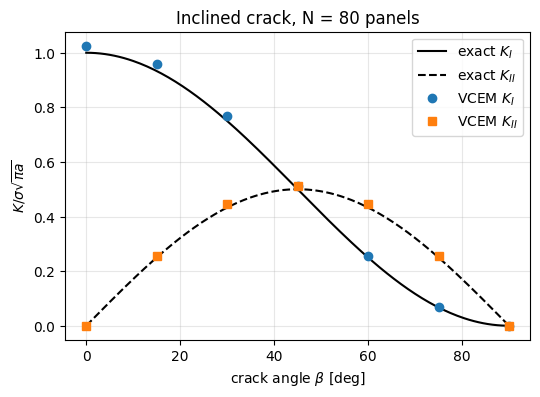

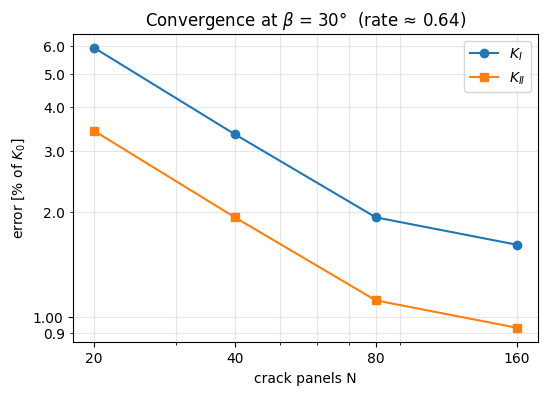

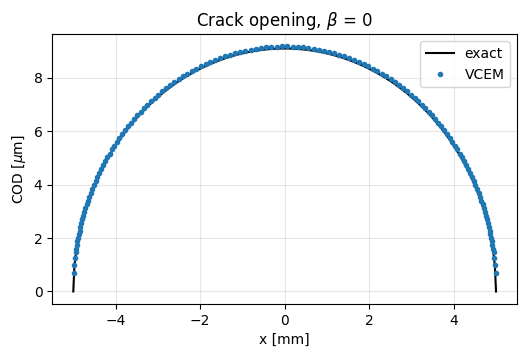

In [7]:
run_dir, run_label = tu.make_run_dir(TUT_DIR, P["label"])
plots = run_dir / "plots"
dpi = int(P["dpi"])
print("run directory:", run_dir.relative_to(TUT_DIR))

b = np.array([r["beta_deg"] for r in sweep])
bb = np.linspace(0, 90, 181)
ex = np.array([exact_K(v) for v in bb]) / K0

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bb, ex[:, 0], "k-", lw=1.5, label=r"exact $K_I$")
ax.plot(bb, ex[:, 1], "k--", lw=1.5, label=r"exact $K_{II}$")
ax.plot(b, [r["KI_num"] / K0 for r in sweep], "o", color="tab:blue", label=r"VCEM $K_I$")
ax.plot(b, [r["KII_num"] / K0 for r in sweep], "s", color="tab:orange", label=r"VCEM $K_{II}$")
ax.set(xlabel=r"crack angle $\beta$ [deg]", ylabel=r"$K / \sigma\sqrt{\pi a}$",
       title=f"Inclined crack, N = {n_prod} panels")
ax.grid(alpha=0.3); ax.legend()
fig.savefig(plots / "K_vs_angle.png", dpi=dpi, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(ns, eI * 100, "o-", label=r"$K_I$")
ax.loglog(ns, np.array([c["err_KII"] for c in conv]) * 100, "s-", label=r"$K_{II}$")
ax.set(xlabel="crack panels N", ylabel=r"error [% of $K_0$]",
       title=rf"Convergence at $\beta$ = {beta_c:g}°  (rate ≈ {rate:.2f})")
from matplotlib.ticker import NullFormatter, ScalarFormatter
ax.set_xticks(ns); ax.xaxis.set_major_formatter(ScalarFormatter()); ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter()); ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.grid(alpha=0.3, which="both"); ax.legend()
fig.savefig(plots / "K_convergence.png", dpi=dpi, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(6, 3.5))
xs = np.linspace(-a, a, 400)
ax.plot(xs * 1e3, 4 * float(P["sigma_yy"]) / E_prime * np.sqrt(a**2 - xs**2) * 1e6, "k-", label="exact")
ax.plot(x_c * 1e3, COD * 1e6, ".", color="tab:blue", label="VCEM")
ax.set(xlabel="x [mm]", ylabel=r"COD [$\mu$m]", title=r"Crack opening, $\beta$ = 0")
ax.grid(alpha=0.3); ax.legend()
fig.savefig(plots / "COD_profile.png", dpi=dpi, bbox_inches="tight")

if SHOW_PLOTS:
    plt.show()
plt.close("all")

## 8. Results, diagnostics and provenance

- `angle_sweep.csv`, `convergence.csv`, `cod_profile.csv` — the result tables;
- `summary.csv` — one row per run, so the summaries of many runs concatenate into one table;
- `diagnostics.txt` — pass/fail against the tolerances in the `Verification` sheet;
- `provenance.md` — every input table with overrides applied, the user selections, the solver
  settings, and the runtime, machine and git state.

In [8]:
tu.write_csv(run_dir / "angle_sweep.csv", sweep)
tu.write_csv(run_dir / "convergence.csv", conv)
tu.write_csv(run_dir / "cod_profile.csv",
             [dict(x_m=float(xi), COD_m=float(ci), COD_exact_m=float(ce)) for xi, ci, ce in zip(x_c, COD, COD_exact)])

max_err = max(max(r["err_KI"], r["err_KII"]) for r in sweep)
checks = [
    ("max K error over the angle sweep", max_err, float(P["tol_K"]), "x K0"),
    ("RMS COD error", cod_rms, float(P["tol_COD"]), "x max COD"),
]
ok = tu.write_diagnostics(run_dir / "diagnostics.txt", run_label, checks)

tu.write_csv(run_dir / "summary.csv", [dict(
    run=run_label, engine=ENGINE, n_panels=n_prod, a_m=a, sigma_yy_Pa=float(P["sigma_yy"]),
    max_K_err=max_err, cod_rms_err=cod_rms, conv_rate_KI=rate, status="PASS" if ok else "FAIL")])

tu.write_provenance(
    run_dir, run_label, title="VCEM tutorial 01 (inclined crack SIF)", tables=tables,
    overrides=overrides_applied,
    user_selections=dict(tutorial="01_inclined_crack_sif", case_workbook=tu.repo_relative(case_path),
                         case_sha256=tu.sha256(case_path), engine_requested=P["engine"],
                         engine_used=ENGINE, engine_note=engine_note, domain="infinite plate",
                         betas_deg=tu.parse_list(P["beta_list_deg"]), beta_conv_deg=beta_c),
    solver_config={**{f"solve.{k}": v for k, v in SOLVER_KW.items()},
                   **{f"sif_fit.{k}": v for k, v in FIT_KW.items()},
                   "sif_fit.a_fit": 2 * a, "sif_fit.method": "DisplacementSIF.euclid_from_edge",
                   "n_crack_elements": n_prod, "n_list": tu.parse_list(P["n_list"], int)},
    run_stats=dict(wall_clock_sweep_s=t_sweep, wall_clock_convergence_s=t_conv,
                   n_solves=len(sweep) + len(conv) + 1, run_status="completed",
                   diagnostics="PASS" if ok else "FAIL"))

print((run_dir / "diagnostics.txt").read_text())
print("files:", sorted(p.name for p in run_dir.iterdir()))

Diagnostics â€” 20260929_180254_inclined_crack_1d7539c8

[PASS] max K error over the angle sweep: 0.02575 x K0 (tolerance 0.05 x K0)
[PASS] RMS COD error: 0.008953 x max COD (tolerance 0.05 x max COD)

Overall: PASS

files: ['angle_sweep.csv', 'cod_profile.csv', 'convergence.csv', 'diagnostics.txt', 'plots', 'provenance.md', 'summary.csv']


## 9. Try this

1. **Biaxial load.** Set `OVERRIDES = {"sigma_xx": 100e6}`. Under equal biaxial tension $K_I$ no
   longer depends on $\beta$ and $K_{II} = 0$.
2. **Coarse mesh.** Set `{"n_crack_elements": 20}` and watch the diagnostics fail. Where does
   the error come from?
3. **Plane stress.** Set `{"plane": "stress"}`. The SIFs do not change, but the COD does,
   through $E'$.
4. **Compare runs.** Open two `provenance.md` files side by side: every difference between the runs is
   listed there.

Next: [Tutorial 02](../02_crack_kinking_growth/02_crack_kinking_growth.ipynb) lets the crack grow.